In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from sklearn.metrics import pairwise_distances
from mpl_toolkits.basemap import Basemap
import glob
import matplotlib as matplotlib
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

In [2]:
#bounding box 

minlat = 34.56
maxlat = 35.56
minlon = -90.66
maxlon = -89.66

# coordinates of site
POI_lon = -90.16
POI_lat = 35.06

In [3]:
#opens all 2023 tempo data
ds2023 = xr.open_mfdataset(f'/data/daniel/TEMPO/Daily_TEMPO_Memphis_2023_2025/tempo_2023*.nc',  combine='by_coords', chunks={'time': 1})
print(ds2023)

#averages all values throughout each month, s.t. each pixel is the monthly avg
dsmonth2023 = ds2023.resample(time="ME").mean()
dsmonth2023



<xarray.Dataset> Size: 126MB
Dimensions:    (time: 1547, lat: 101, lon: 101)
Coordinates:
  * time       (time) datetime64[ns] 12kB 2023-09-01T10:56:14 ... 2023-12-31T...
    latitude   (lat, lon) float32 41kB dask.array<chunksize=(101, 101), meta=np.ndarray>
    longitude  (lat, lon) float32 41kB dask.array<chunksize=(101, 101), meta=np.ndarray>
Dimensions without coordinates: lat, lon
Data variables:
    NO2        (time, lat, lon) float64 126MB dask.array<chunksize=(1, 101, 101), meta=np.ndarray>


<xarray.Dataset> Size: 408kB
Dimensions:    (time: 4, lat: 101, lon: 101)
Coordinates:
  * time       (time) datetime64[ns] 32B 2023-09-30 2023-10-31 ... 2023-12-31
    latitude   (lat, lon) float32 41kB dask.array<chunksize=(101, 101), meta=np.ndarray>
    longitude  (lat, lon) float32 41kB dask.array<chunksize=(101, 101), meta=np.ndarray>
Dimensions without coordinates: lat, lon
Data variables:
    NO2        (time, lat, lon) float64 326kB dask.array<chunksize=(1, 101, 101), meta=np.ndarray>

In [4]:
#opens all 2024 tempo data
ds2024 = xr.open_mfdataset(f'/data/daniel/TEMPO/Daily_TEMPO_Memphis_2023_2025/tempo_2024*.nc',  combine='by_coords', chunks={'time': 1})
print(ds2024)

#averages all values throughout dach month, s.t. each pixel is the monthly avg
dsmonth2024 = ds2024.resample(time="ME").mean()
dsmonth2024

dsmonth2024.time


<xarray.Dataset> Size: 402MB
Dimensions:    (time: 4922, lat: 101, lon: 101)
Coordinates:
  * time       (time) datetime64[ns] 39kB 2024-01-01T12:51:57 ... 2024-12-31T...
    latitude   (lat, lon) float32 41kB dask.array<chunksize=(101, 101), meta=np.ndarray>
    longitude  (lat, lon) float32 41kB dask.array<chunksize=(101, 101), meta=np.ndarray>
Dimensions without coordinates: lat, lon
Data variables:
    NO2        (time, lat, lon) float64 402MB dask.array<chunksize=(1, 101, 101), meta=np.ndarray>


<xarray.DataArray 'time' (time: 12)> Size: 96B
array(['2024-01-31T00:00:00.000000000', '2024-02-29T00:00:00.000000000',
       '2024-03-31T00:00:00.000000000', '2024-04-30T00:00:00.000000000',
       '2024-05-31T00:00:00.000000000', '2024-06-30T00:00:00.000000000',
       '2024-07-31T00:00:00.000000000', '2024-08-31T00:00:00.000000000',
       '2024-09-30T00:00:00.000000000', '2024-10-31T00:00:00.000000000',
       '2024-11-30T00:00:00.000000000', '2024-12-31T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 96B 2024-01-31 2024-02-29 ... 2024-12-31

In [5]:
#opens all 2025 tempo data
ds2025 = xr.open_mfdataset(f'/data/daniel/TEMPO/Daily_TEMPO_Memphis_2023_2025/tempo_2025*.nc',  combine='by_coords', chunks={'time': 1})
print(ds2025)

#averages all values throughout dach month, st each pixel is the monthly avg
dsmonth2025 = ds2025.resample(time="ME").mean()
dsmonth2025

dsmonth2025.time


<xarray.Dataset> Size: 281MB
Dimensions:    (time: 3438, lat: 101, lon: 101)
Coordinates:
  * time       (time) datetime64[ns] 28kB 2025-01-01T12:48:02 ... 2025-09-01T...
    latitude   (lat, lon) float32 41kB dask.array<chunksize=(101, 101), meta=np.ndarray>
    longitude  (lat, lon) float32 41kB dask.array<chunksize=(101, 101), meta=np.ndarray>
Dimensions without coordinates: lat, lon
Data variables:
    NO2        (time, lat, lon) float64 281MB dask.array<chunksize=(1, 101, 101), meta=np.ndarray>


<xarray.DataArray 'time' (time: 9)> Size: 72B
array(['2025-01-31T00:00:00.000000000', '2025-02-28T00:00:00.000000000',
       '2025-03-31T00:00:00.000000000', '2025-04-30T00:00:00.000000000',
       '2025-05-31T00:00:00.000000000', '2025-06-30T00:00:00.000000000',
       '2025-07-31T00:00:00.000000000', '2025-08-31T00:00:00.000000000',
       '2025-09-30T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 72B 2025-01-31 2025-02-28 ... 2025-09-30

In [6]:
#selects the data in the month of interest. 

no2sep2023 = dsmonth2023.NO2.sel(time='2023-09-30T00:00:00.000000000')
no2oct2023 = dsmonth2023.NO2.sel(time='2023-10-31T00:00:00.000000000')
no2nov2023 = dsmonth2023.NO2.sel(time='2023-11-30T00:00:00.000000000')
no2dec2023 = dsmonth2023.NO2.sel(time='2023-12-31T00:00:00.000000000')


no2jan2024 = dsmonth2024.NO2.sel(time='2024-01-31T00:00:00.000000000')
no2feb2024 = dsmonth2024.NO2.sel(time='2024-02-29T00:00:00.000000000')
no2mar2024 = dsmonth2024.NO2.sel(time='2024-03-31T00:00:00.000000000')
no2apr2024 = dsmonth2024.NO2.sel(time='2024-04-30T00:00:00.000000000')
no2may2024 = dsmonth2024.NO2.sel(time='2024-05-31T00:00:00.000000000')
no2jun2024 = dsmonth2024.NO2.sel(time='2024-06-30T00:00:00.000000000')
no2jul2024 = dsmonth2024.NO2.sel(time='2024-07-31T00:00:00.000000000')
no2aug2024 = dsmonth2024.NO2.sel(time='2024-08-31T00:00:00.000000000')
no2sep2024 = dsmonth2024.NO2.sel(time='2024-09-30T00:00:00.000000000')
no2oct2024 = dsmonth2024.NO2.sel(time='2024-10-31T00:00:00.000000000')
no2nov2024 = dsmonth2024.NO2.sel(time='2024-11-30T00:00:00.000000000')
no2dec2024 = dsmonth2024.NO2.sel(time='2024-12-31T00:00:00.000000000')

no2jan2025 = dsmonth2025.NO2.sel(time='2025-01-31T00:00:00.000000000')
no2feb2025 = dsmonth2025.NO2.sel(time='2025-02-28T00:00:00.000000000')
no2mar2025 = dsmonth2025.NO2.sel(time='2025-03-31T00:00:00.000000000')
no2apr2025 = dsmonth2025.NO2.sel(time='2025-04-30T00:00:00.000000000')
no2may2025 = dsmonth2025.NO2.sel(time='2025-05-31T00:00:00.000000000')
no2jun2025 = dsmonth2025.NO2.sel(time='2025-06-30T00:00:00.000000000')
no2jul2025 = dsmonth2025.NO2.sel(time='2025-07-31T00:00:00.000000000')
no2aug2025 = dsmonth2025.NO2.sel(time='2025-08-31T00:00:00.000000000')


<Figure size 640x480 with 0 Axes>

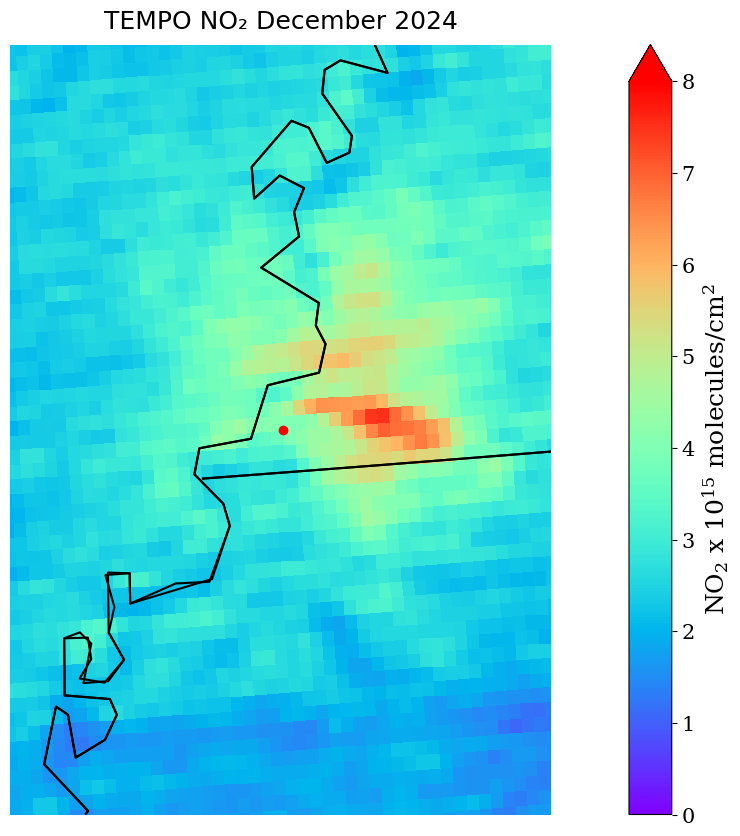

In [7]:
# Plotting the data
plt.clf()  # Clears any existing figures
fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(111, frame_on=False)

# this sets the base map to the area you want to plot
m = Basemap(
    projection='lcc', lat_0=40., lat_1=33., lat_2=45., lon_0=-97.,
    resolution='i', area_thresh=10000., rsphere=(6378137.00, 6356752.3142),
    llcrnrlon=minlon, llcrnrlat=minlat, urcrnrlon=maxlon, urcrnrlat=maxlat
)

# this will draw the state boundaries and coastlines
try:
    m.drawcoastlines()
except:
    pass
m.drawcountries(linewidth=1.5)
m.drawstates(linewidth=1.5)

# Define colormap and normalization for NO2 mean values
colors = 'rainbow' #can change the coloring of the map here; go here for different colorschemes https://matplotlib.org/stable/users/explain/colors/colormaps.html
norm = plt.Normalize(vmin=0, vmax=8) # all values greater than 8 will be set to red

# Plot the NO2 mean values; change the no2 month as needed in the mesh line
plt.rcParams["font.family"] = "serif" #this is the font of the text
mesh = m.pcolormesh(no2dec2024.longitude, no2dec2024.latitude, no2dec2024.values, cmap=colors, norm=norm, shading='nearest', latlon=True) 

m.plot(POI_lon, POI_lat, marker='o', color='red', markersize=6, latlon = True)


# Create the colorbar and set the tick parameters
cbar = plt.colorbar(mesh, aspect=18, extend='max')
cbar.ax.tick_params(labelsize=15)
cbar.set_label(label=r'NO$\mathregular{_2}$ x $\mathregular{10^{15}}$ molecules/cm$\mathregular{^2}$', fontsize=18) #color bar label

plt.title('TEMPO NO₂ December 2024', fontsize=18, y=1.01) #comment this out if you don't want a title

# plt.savefig('TEMPO NO₂ June 2024.jpg', bbox_inches='tight') #change the title of the output image here
plt.show()



<Figure size 640x480 with 0 Axes>

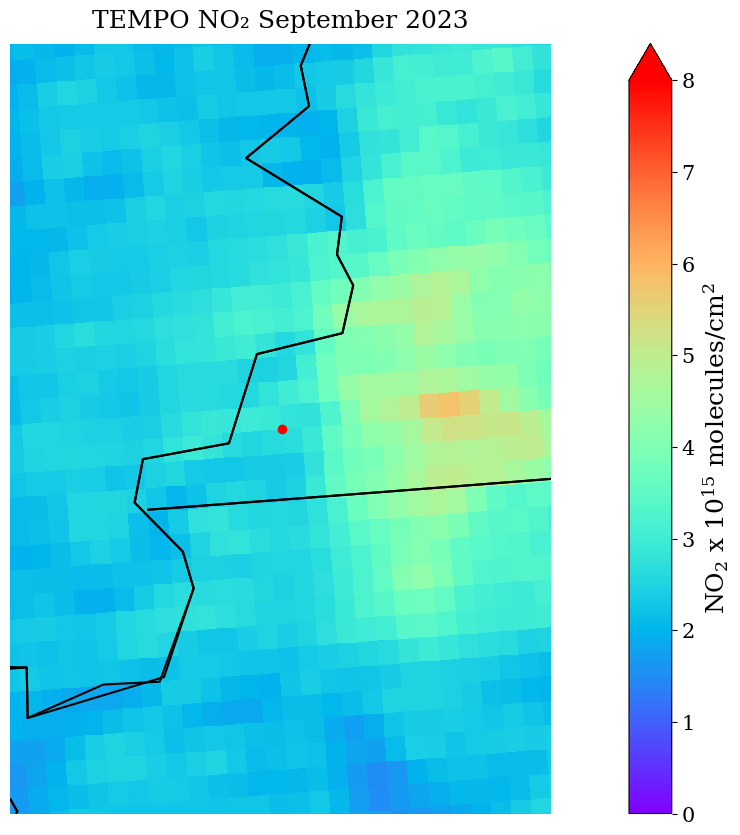

<Figure size 640x480 with 0 Axes>

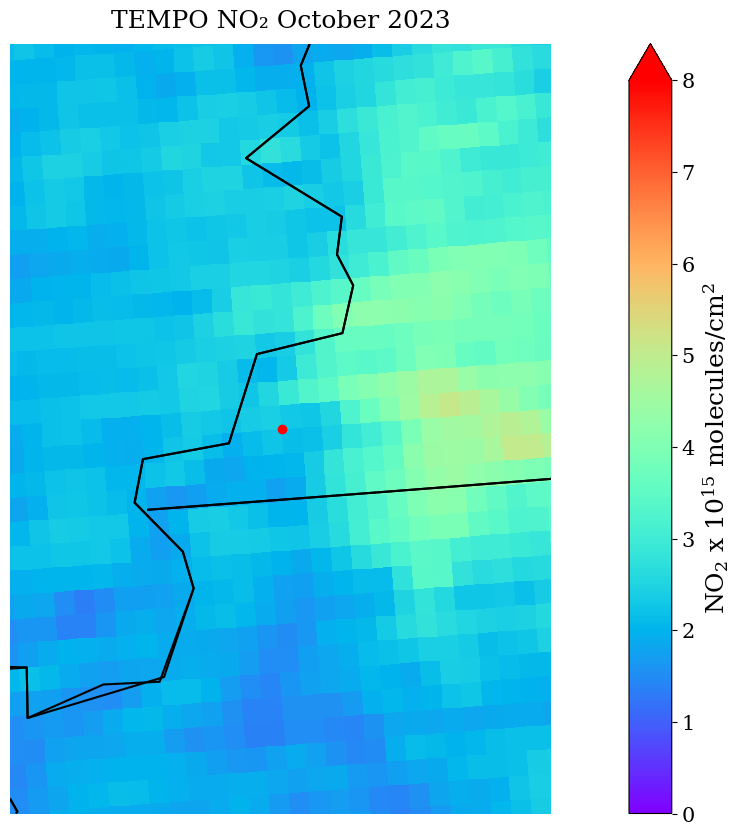

<Figure size 640x480 with 0 Axes>

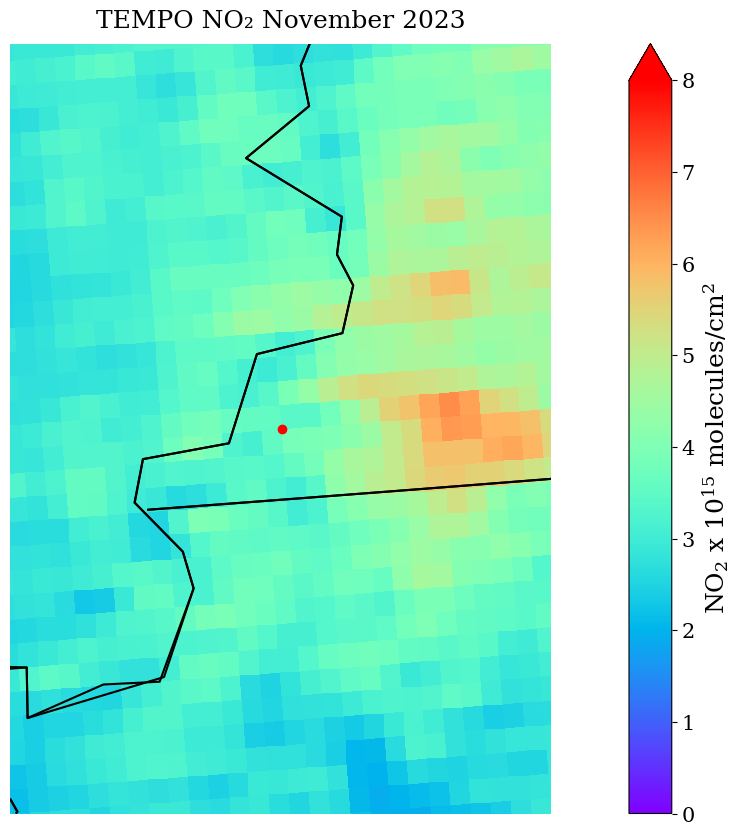

<Figure size 640x480 with 0 Axes>

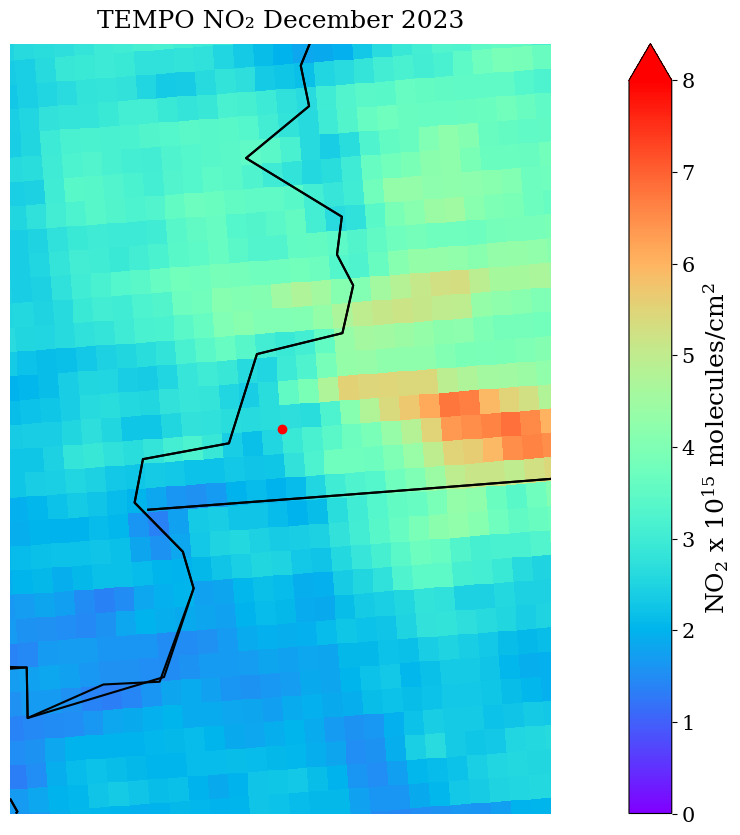

<Figure size 640x480 with 0 Axes>

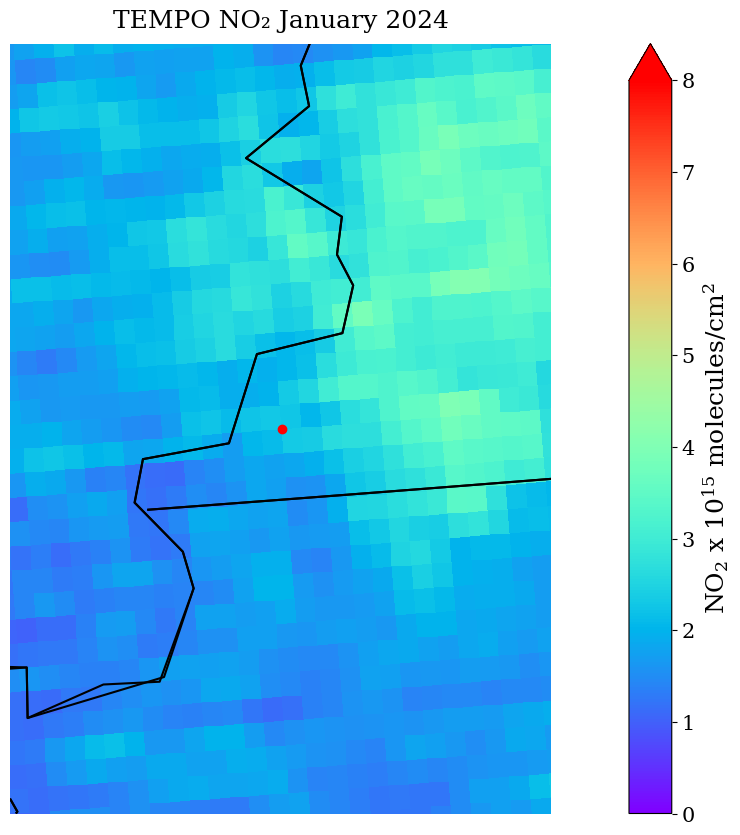

<Figure size 640x480 with 0 Axes>

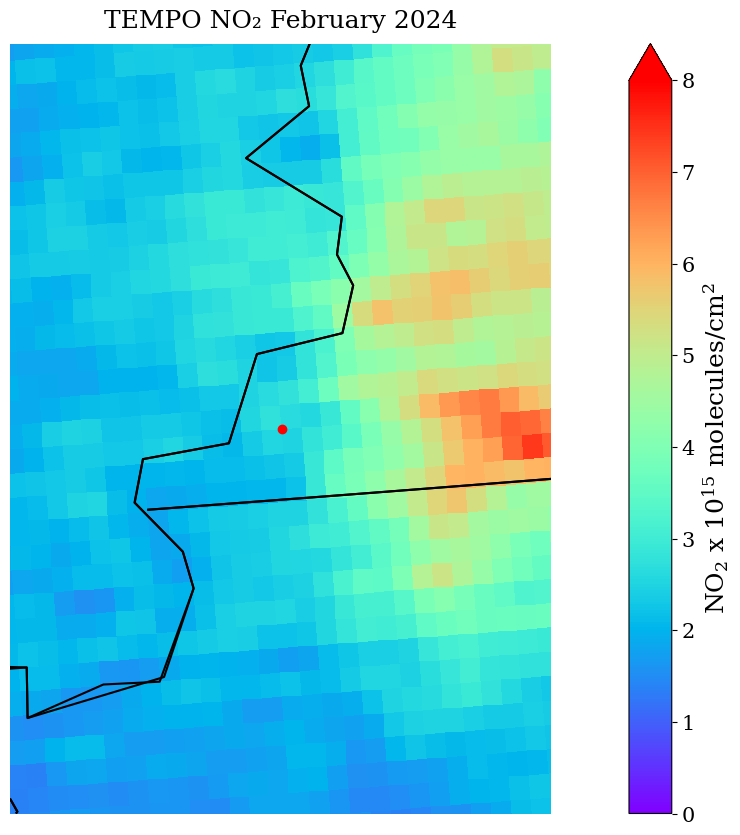

<Figure size 640x480 with 0 Axes>

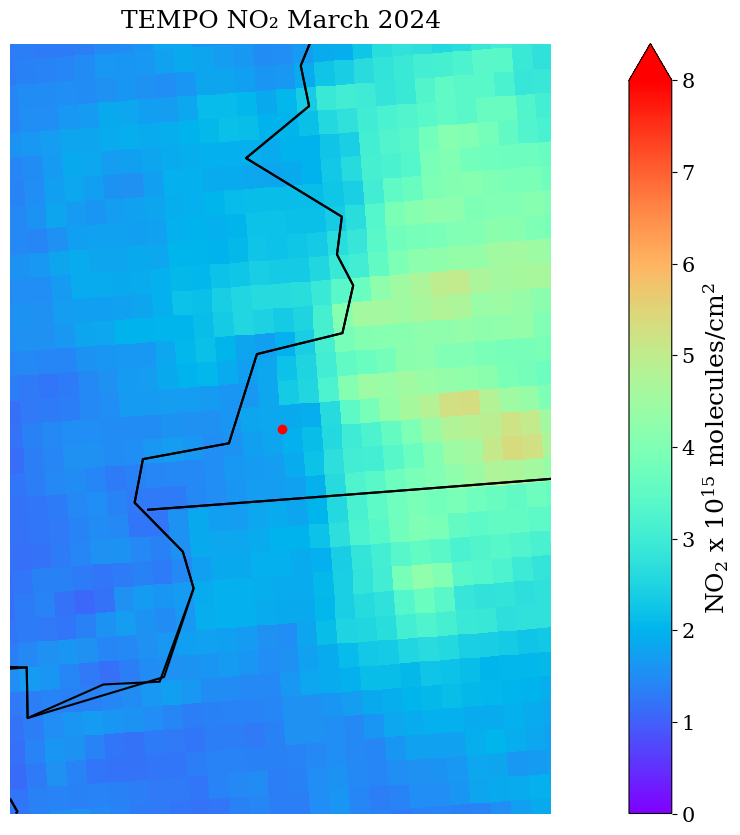

<Figure size 640x480 with 0 Axes>

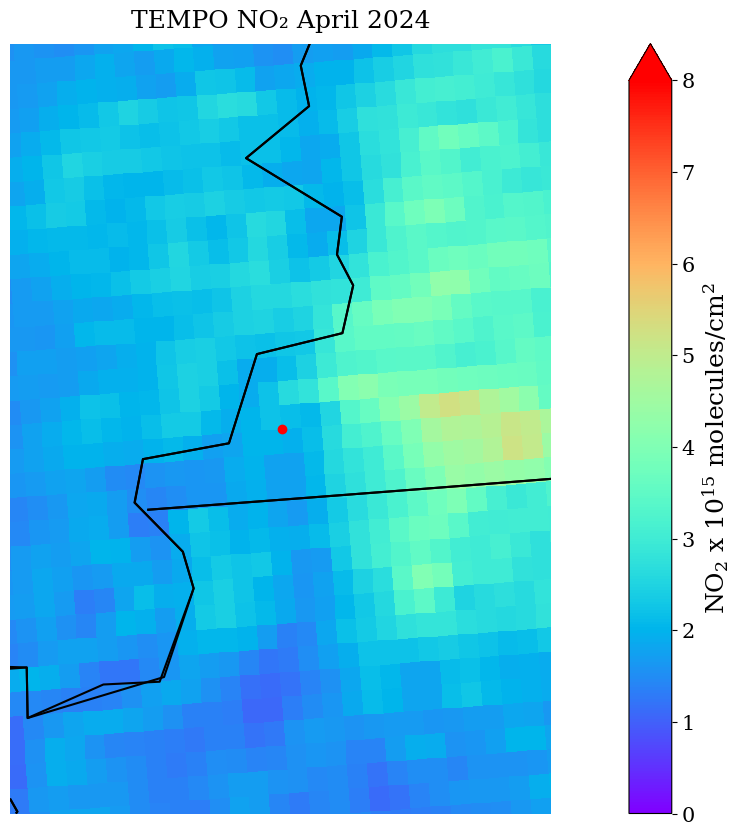

<Figure size 640x480 with 0 Axes>

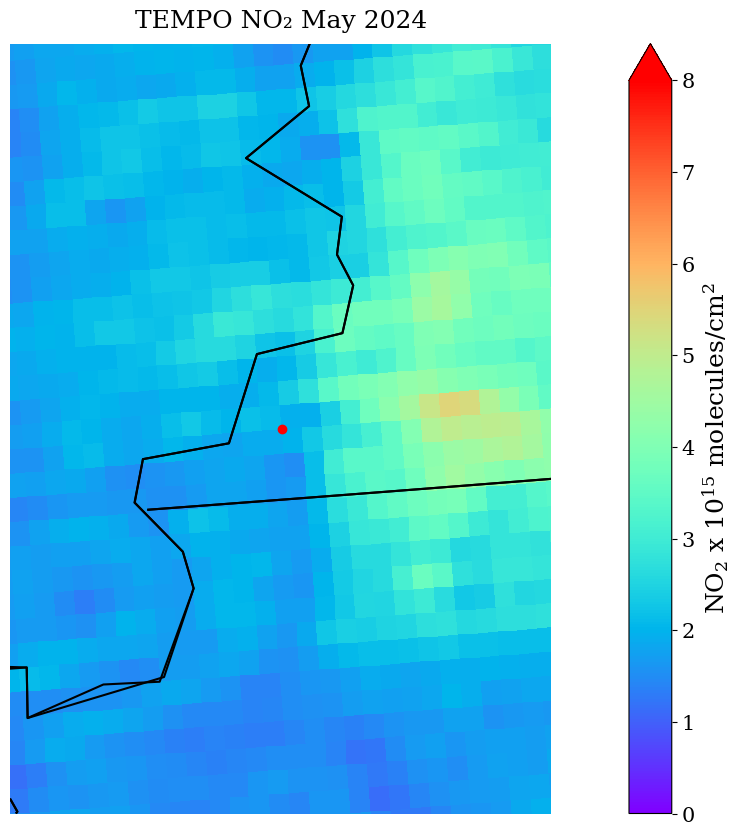

<Figure size 640x480 with 0 Axes>

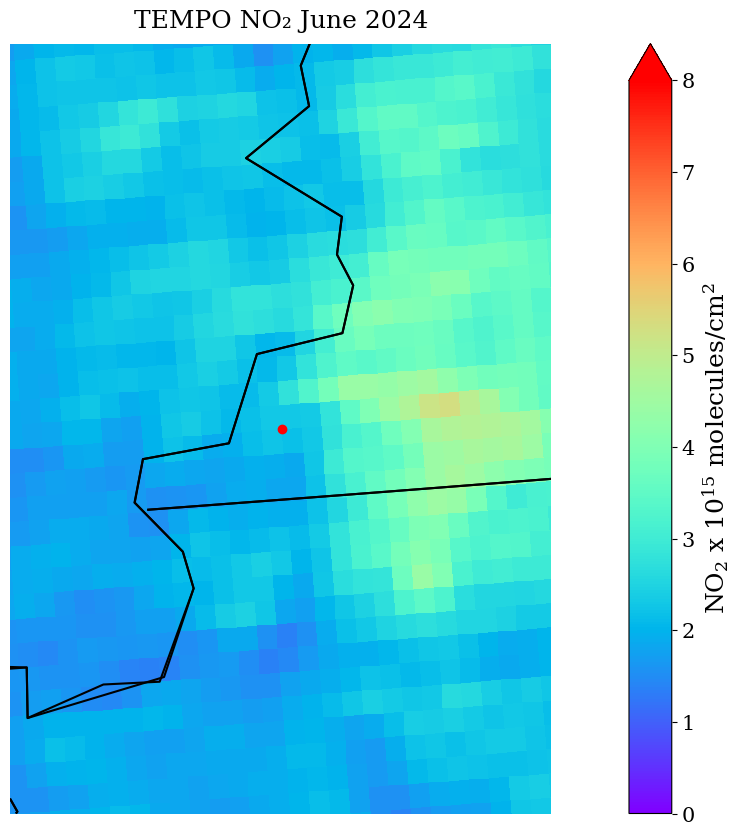

<Figure size 640x480 with 0 Axes>

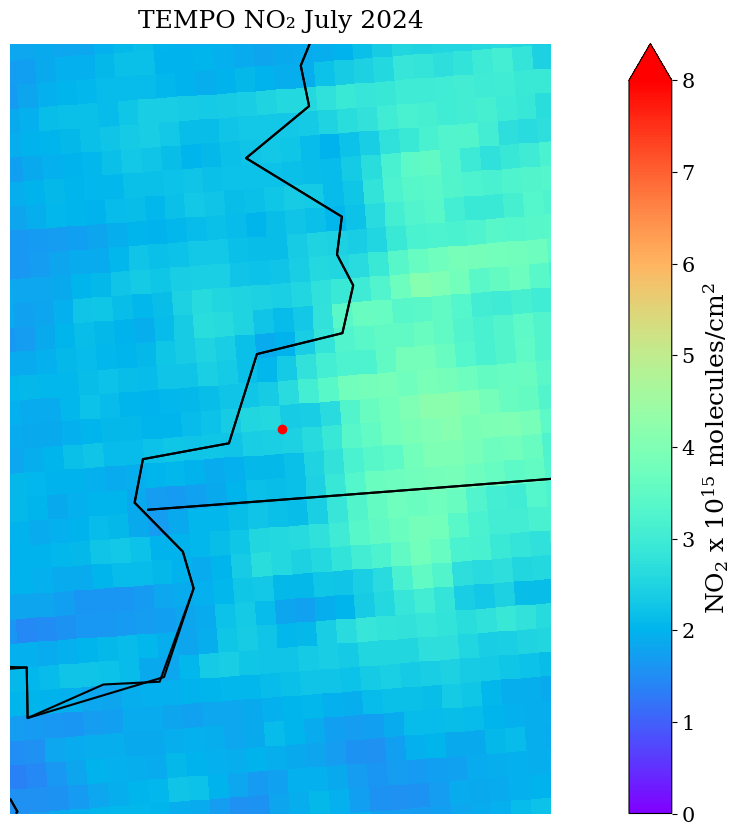

<Figure size 640x480 with 0 Axes>

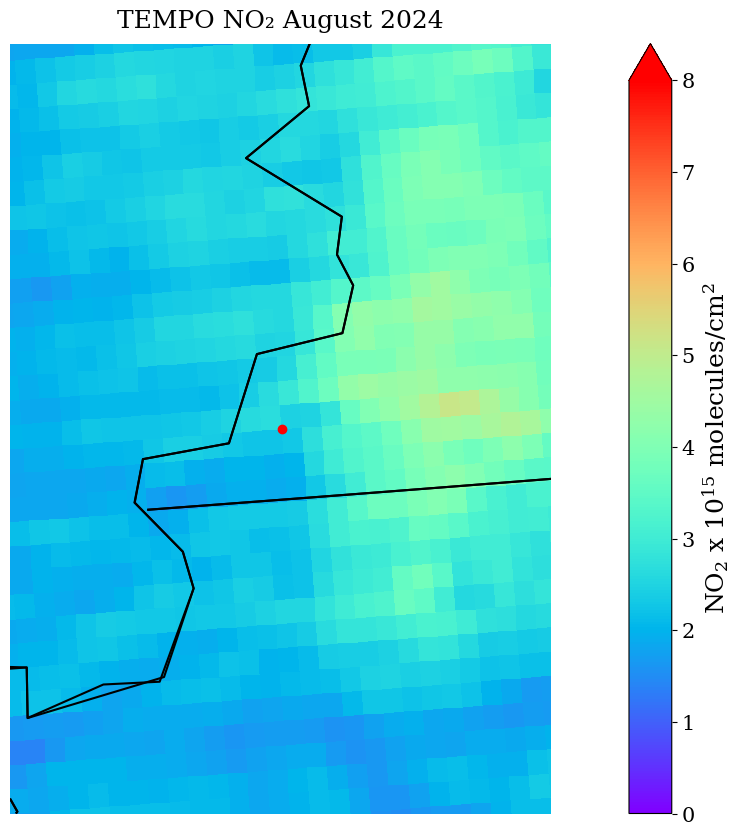

<Figure size 640x480 with 0 Axes>

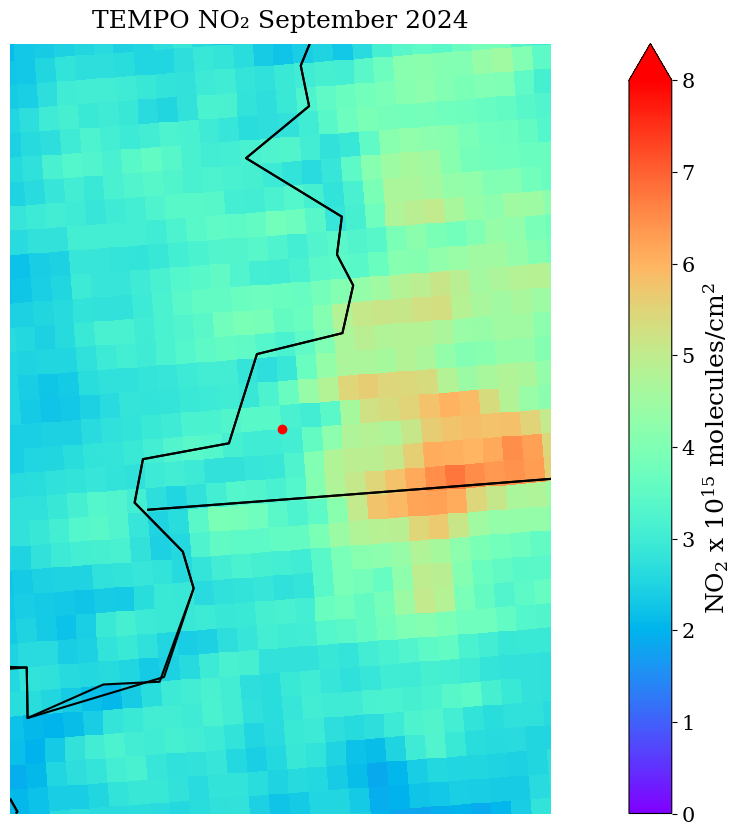

<Figure size 640x480 with 0 Axes>

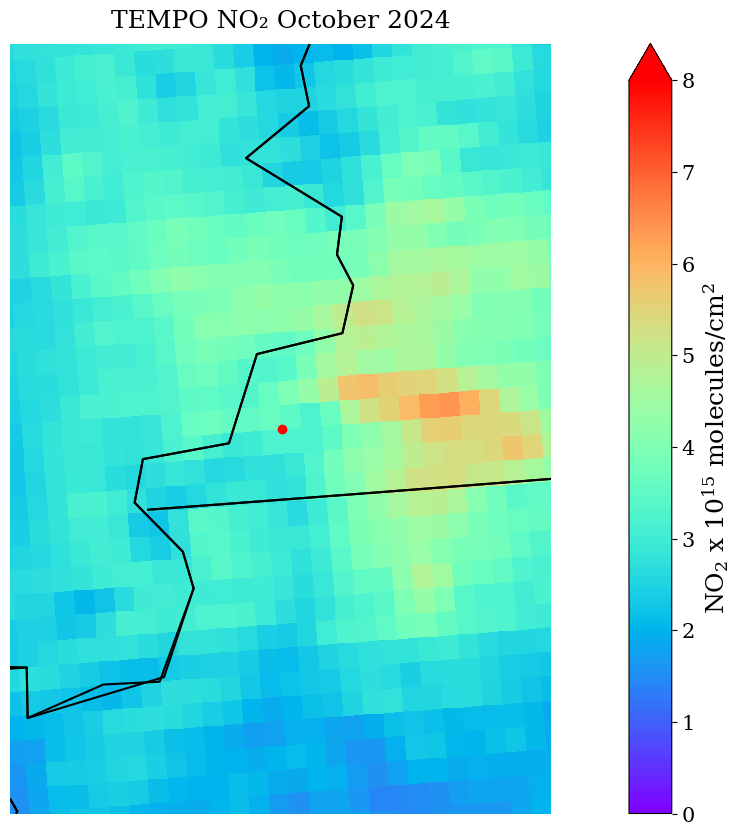

<Figure size 640x480 with 0 Axes>

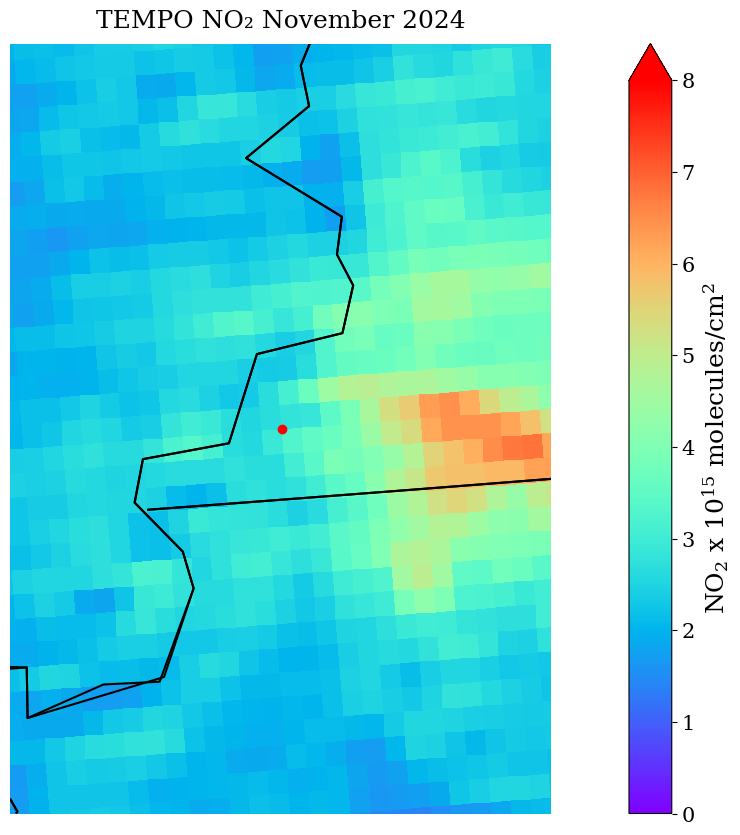

<Figure size 640x480 with 0 Axes>

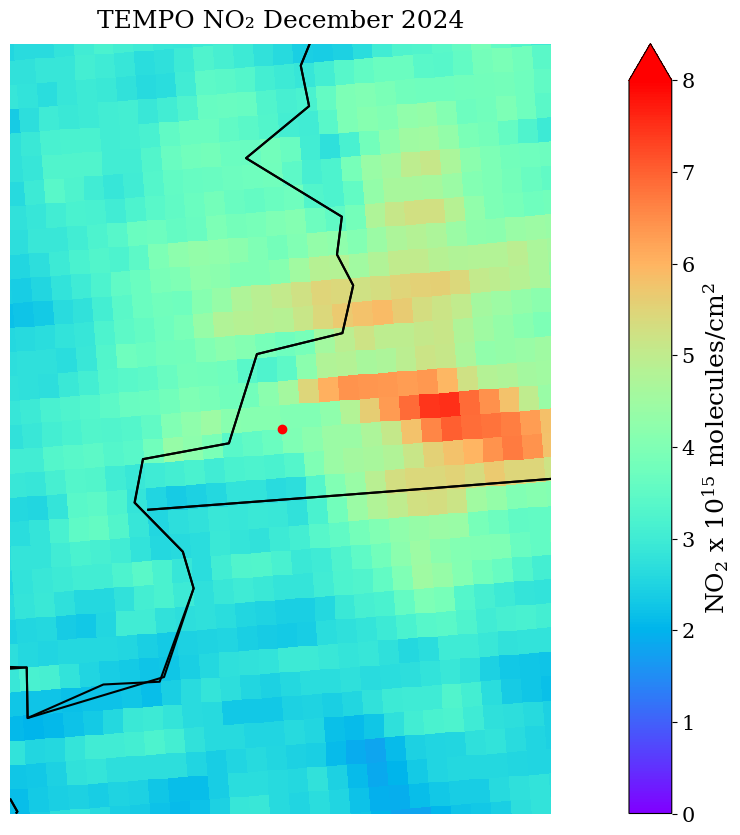

<Figure size 640x480 with 0 Axes>

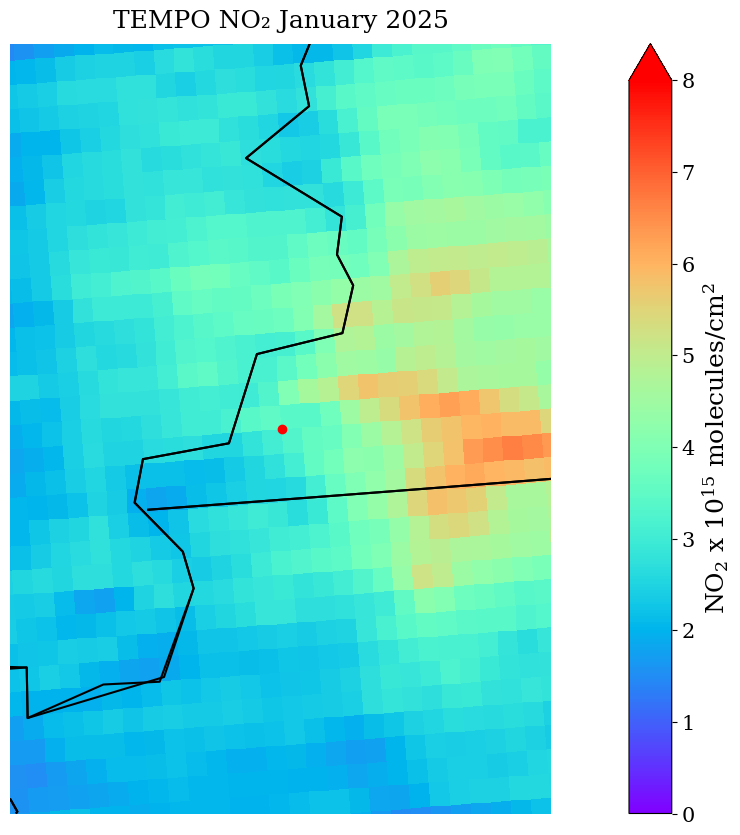

<Figure size 640x480 with 0 Axes>

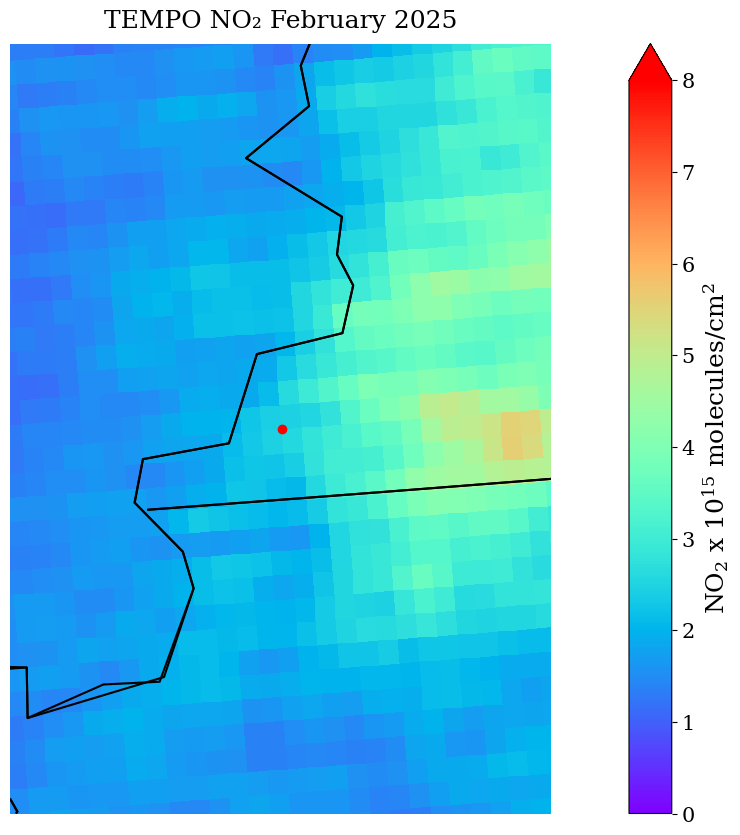

<Figure size 640x480 with 0 Axes>

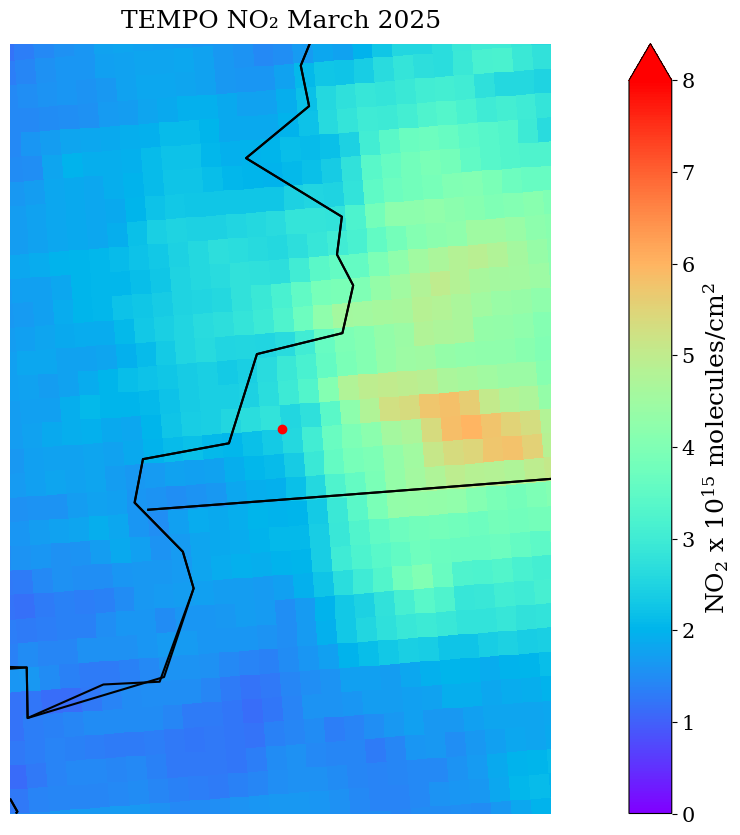

<Figure size 640x480 with 0 Axes>

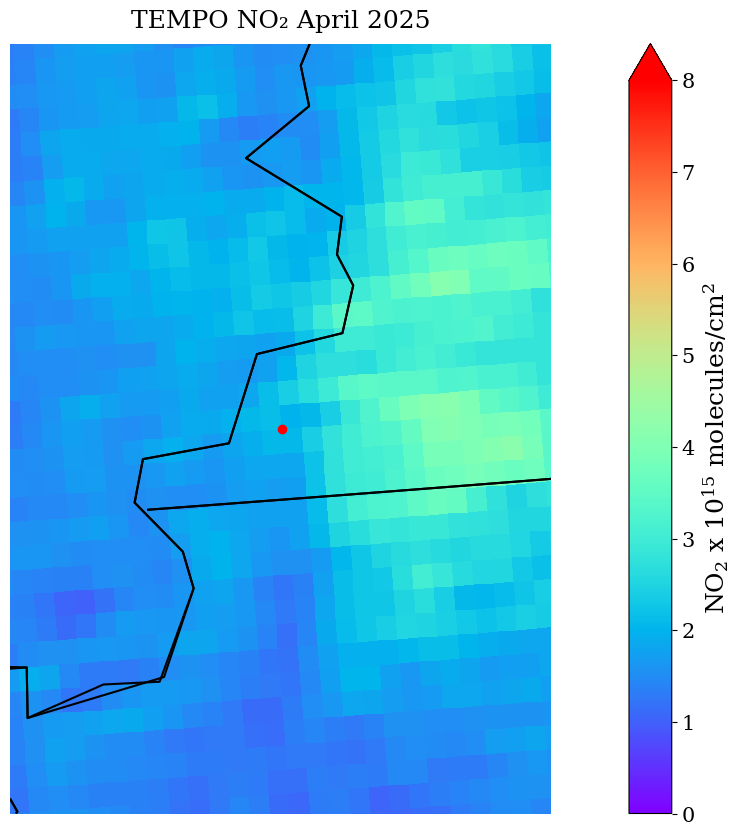

<Figure size 640x480 with 0 Axes>

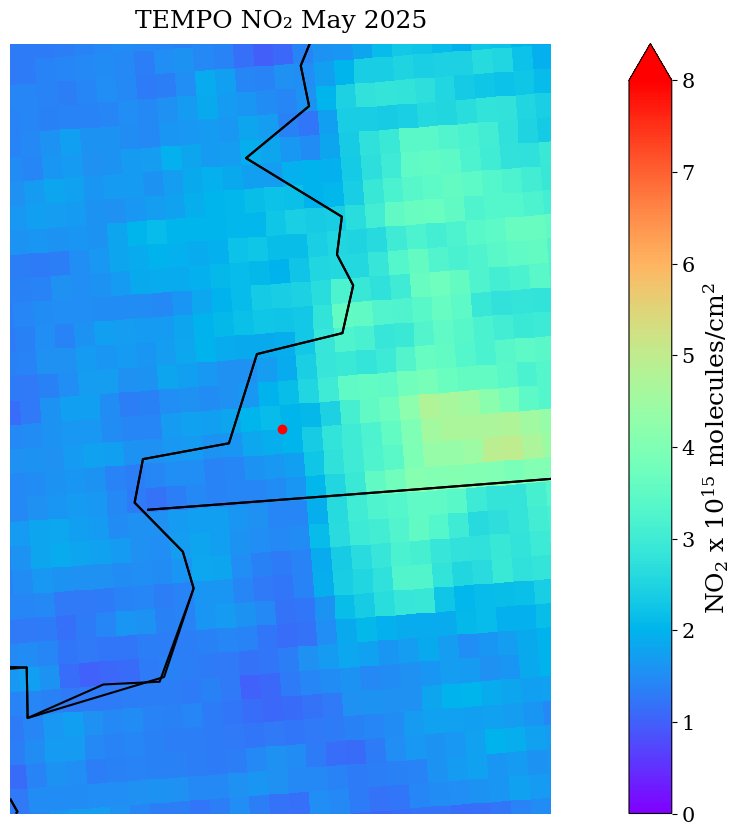

<Figure size 640x480 with 0 Axes>

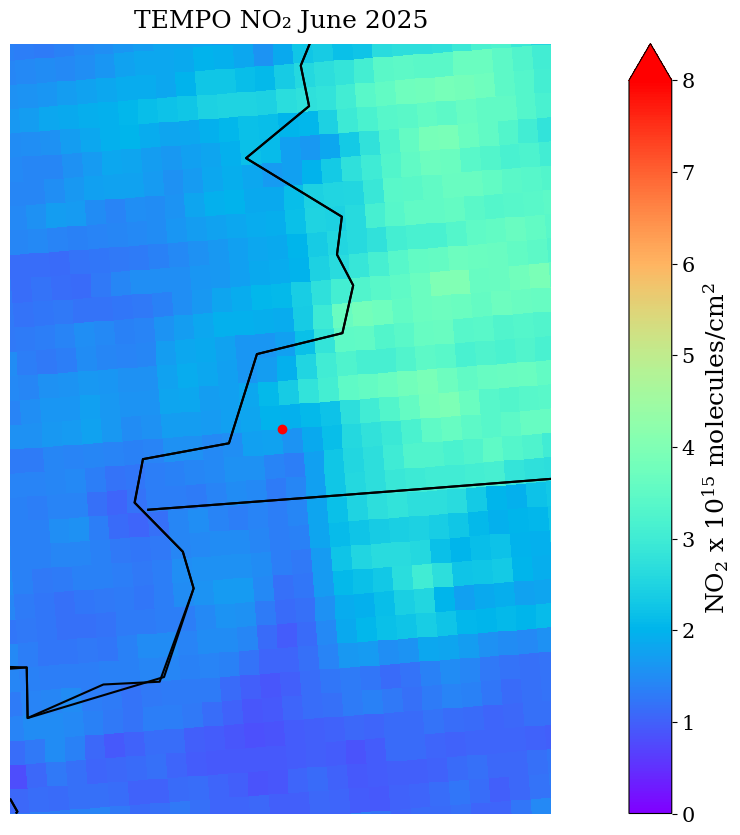

<Figure size 640x480 with 0 Axes>

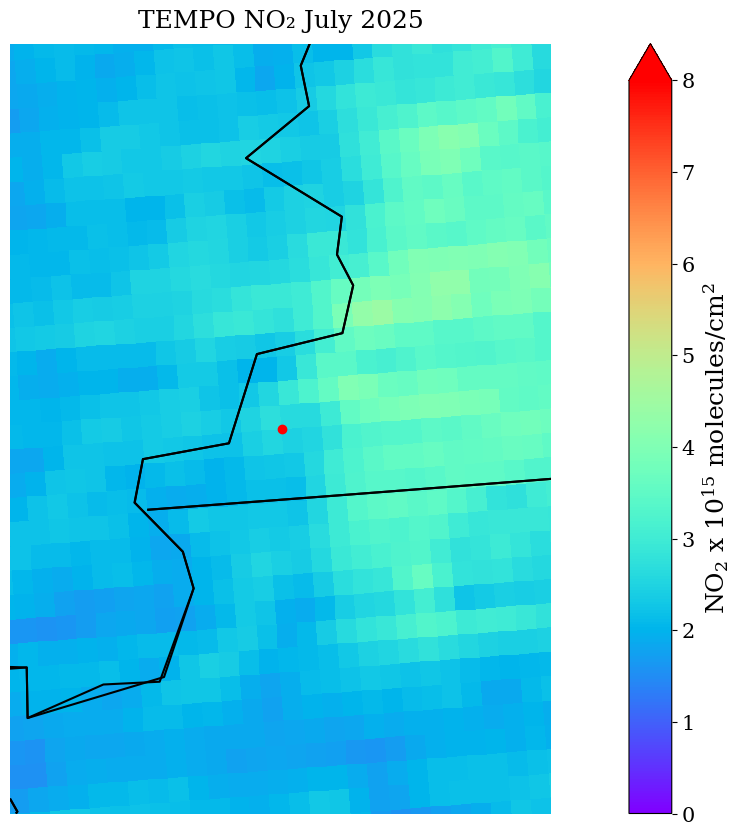

<Figure size 640x480 with 0 Axes>

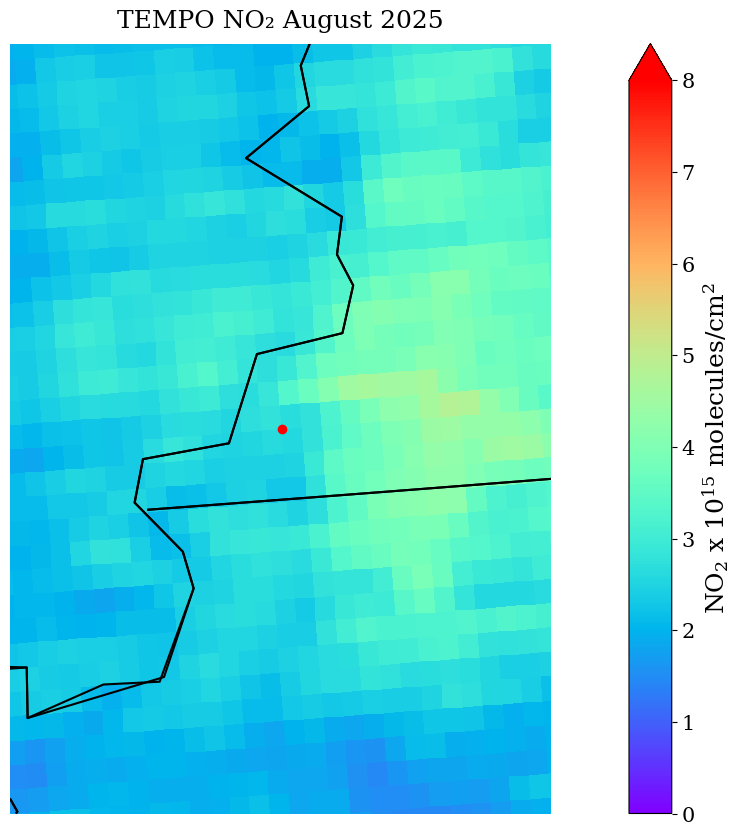

In [8]:
## function for plotting all 24 months and exporting a individual jpegs
def plot_no2_abs(data, month_label, filename,
                 vmin=0, vmax=8,
                 minlat=34.76, maxlat=35.36,
                 minlon=-90.46, maxlon=-89.86):

    plt.clf()
    fig = plt.figure(figsize=(20, 10))
    ax = fig.add_subplot(111, frame_on=False)

    m = Basemap(
        projection='lcc', lat_0=40., lat_1=33., lat_2=45., lon_0=-97.,
        resolution='i', area_thresh=10000., rsphere=(6378137.00, 6356752.3142),
        llcrnrlon=minlon, llcrnrlat=minlat, urcrnrlon=maxlon, urcrnrlat=maxlat
    )

    try:
        m.drawcoastlines()
    except:
        pass
    m.drawcountries(linewidth=1.5)
    m.drawstates(linewidth=1.5)

    colors = 'rainbow'
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    plt.rcParams["font.family"] = "serif"

    mesh = m.pcolormesh(data.longitude, data.latitude, data.values,
                        cmap=colors, norm=norm, shading='nearest', latlon=True)
    m.plot(POI_lon, POI_lat, marker='o', color='red', markersize=6, latlon=True)

    cbar = plt.colorbar(mesh, aspect=18, extend='max')
    cbar.ax.tick_params(labelsize=15)
    cbar.set_label(label=r'NO$\mathregular{_2}$ x $\mathregular{10^{15}}$ molecules/cm$\mathregular{^2}$',
                   fontsize=18)

    plt.title(f'TEMPO NO₂ {month_label}', fontsize=18, y=1.01)
  ##  plt.savefig(f'{filename}.jpg', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig)

monthly_data_abs = [
    (no2sep2023, 'September 2023', 'TEMPO NO₂ September 2023'),
    (no2oct2023, 'October 2023',   'TEMPO NO₂ October 2023'),
    (no2nov2023, 'November 2023',  'TEMPO NO₂ November 2023'),
    (no2dec2023, 'December 2023',  'TEMPO NO₂ December 2023'),
    (no2jan2024, 'January 2024',   'TEMPO NO₂ January 2024'),
    (no2feb2024, 'February 2024',  'TEMPO NO₂ February 2024'),
    (no2mar2024, 'March 2024',     'TEMPO NO₂ March 2024'),
    (no2apr2024, 'April 2024',     'TEMPO NO₂ April 2024'),
    (no2may2024, 'May 2024',       'TEMPO NO₂ May 2024'),
    (no2jun2024, 'June 2024',      'TEMPO NO₂ June 2024'),
    (no2jul2024, 'July 2024',      'TEMPO NO₂ July 2024'),
    (no2aug2024, 'August 2024',    'TEMPO NO₂ August 2024'),
    (no2sep2024, 'September 2024', 'TEMPO NO₂ September 2024'),
    (no2oct2024, 'October 2024',   'TEMPO NO₂ October 2024'),
    (no2nov2024, 'November 2024',  'TEMPO NO₂ November 2024'),
    (no2dec2024, 'December 2024',  'TEMPO NO₂ December 2024'),
    (no2jan2025, 'January 2025',   'TEMPO NO₂ January 2025'),
    (no2feb2025, 'February 2025',  'TEMPO NO₂ February 2025'),
    (no2mar2025, 'March 2025',     'TEMPO NO₂ March 2025'),
    (no2apr2025, 'April 2025',     'TEMPO NO₂ April 2025'),
    (no2may2025, 'May 2025',       'TEMPO NO₂ May 2025'),
    (no2jun2025, 'June 2025',      'TEMPO NO₂ June 2025'),
    (no2jul2025, 'July 2025',      'TEMPO NO₂ July 2025'),
    (no2aug2025, 'August 2025',    'TEMPO NO₂ August 2025'),
]

for data, label, filename in monthly_data_abs:
    plot_no2_abs(data, label, filename)
    

In [9]:
# create monthly differences(∆ NO2)

no2sepdiff = no2sep2024 - no2sep2023
no2octdiff = no2oct2024 - no2oct2023
no2novdiff = no2nov2024 - no2nov2023
no2decdiff = no2dec2024 - no2dec2023
no2jandiff = no2jan2025 - no2jan2024
no2febdiff = no2feb2025 - no2feb2024
no2mardiff = no2mar2025 - no2mar2024
no2aprdiff = no2apr2025 - no2apr2024
no2maydiff = no2may2025 - no2may2024
no2jundiff = no2jun2025 - no2jun2024
no2juldiff = no2jul2025 - no2jul2024
no2augdiff = no2aug2025 - no2aug2024

<Figure size 640x480 with 0 Axes>

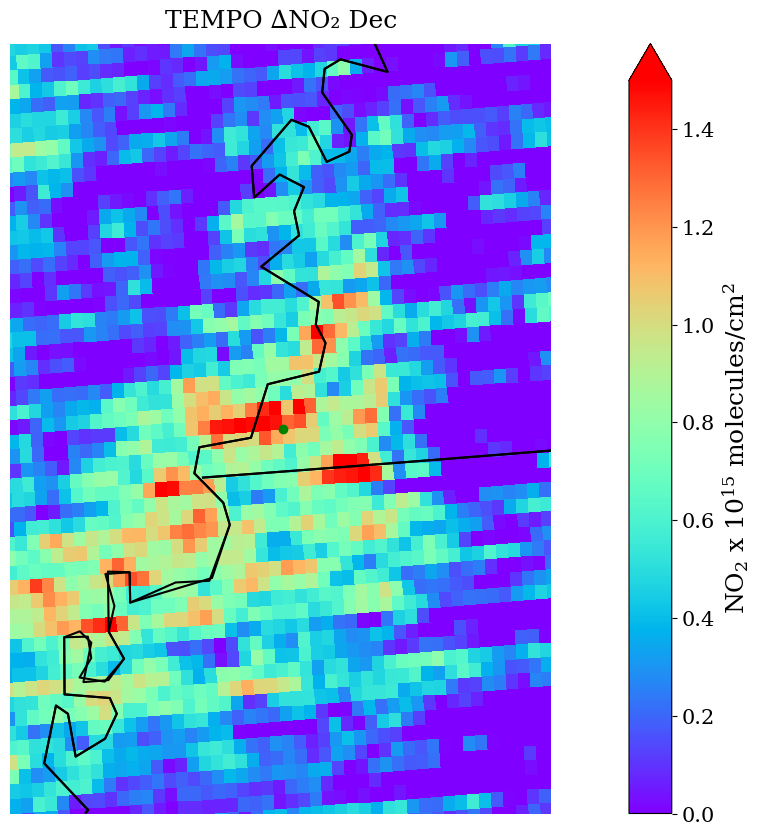

In [10]:
# Plotting the data
plt.clf()  # Clears any existing figures
fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(111, frame_on=False)

# this sets the base map to the area you want to plot
m = Basemap(
    projection='lcc', lat_0=40., lat_1=33., lat_2=45., lon_0=-97.,
    resolution='i', area_thresh=10000., rsphere=(6378137.00, 6356752.3142),
    llcrnrlon=minlon, llcrnrlat=minlat, urcrnrlon=maxlon, urcrnrlat=maxlat
)

# this will draw the state boundaries and coastlines
try:
    m.drawcoastlines()
except:
    pass
m.drawcountries(linewidth=1.5)
m.drawstates(linewidth=1.5)

# Define colormap and normalization for NO2 mean values
colors = 'rainbow' #can change the coloring of the map here; go here for different colorschemes https://matplotlib.org/stable/users/explain/colors/colormaps.html
norm = plt.Normalize(vmin=0, vmax=1.5) # all values greater than 1.5 will be set to red

# Plot the NO2 mean values; change the no2 month as needed in the mesh line
plt.rcParams["font.family"] = "serif" #this is the font of the text
mesh = m.pcolormesh(no2decdiff.longitude, no2decdiff.latitude, no2decdiff.values, cmap=colors, norm=norm, shading='nearest', latlon=True) 

m.plot(POI_lon, POI_lat, marker='o', color='green', markersize=6, latlon = True)


# Create the colorbar and set the tick parameters
cbar = plt.colorbar(mesh, aspect=18, extend='max')
cbar.ax.tick_params(labelsize=15)
cbar.set_label(label=r'NO$\mathregular{_2}$ x $\mathregular{10^{15}}$ molecules/cm$\mathregular{^2}$', fontsize=18) #color bar label

plt.title('TEMPO ∆NO₂ Dec', fontsize=18, y=1.01) 
plt.show()


<Figure size 640x480 with 0 Axes>

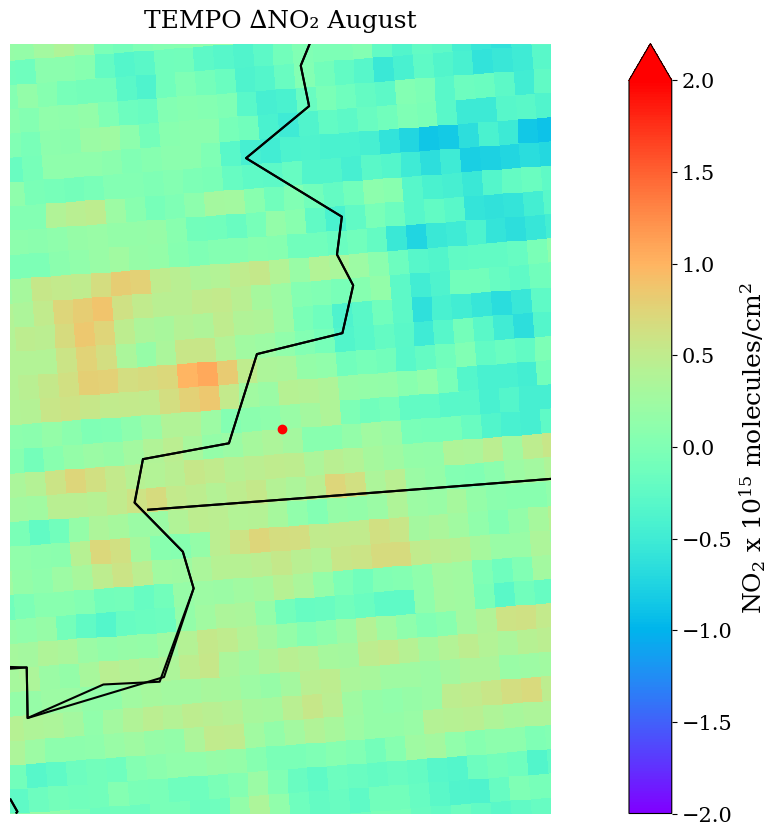

In [11]:
# xAi 35.06, -90.16 (30 km radius from DC)
minlatZOOM = 34.76
maxlatZOOM = 35.36
minlonZOOM = -90.46
maxlonZOOM = -89.86

# Plotting the data
plt.clf()  # Clears any existing figures
fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(111, frame_on=False)

# this sets the base map to the area you want to plot
m = Basemap(
    projection='lcc', lat_0=40., lat_1=33., lat_2=45., lon_0=-97.,
    resolution='i', area_thresh=10000., rsphere=(6378137.00, 6356752.3142),
    llcrnrlon=minlonZOOM, llcrnrlat=minlatZOOM, urcrnrlon=maxlonZOOM, urcrnrlat=maxlatZOOM
)

# this will draw the state boundaries and coastlines
try:
    m.drawcoastlines()
except:
    pass
m.drawcountries(linewidth=1.5)
m.drawstates(linewidth=1.5)

# Define colormap and normalization for NO2 mean values
colors = 'rainbow' #can change the coloring of the map here; go here for different colorschemes https://matplotlib.org/stable/users/explain/colors/colormaps.html
norm = plt.Normalize(vmin=-2.0, vmax=2.0) # all values greater than 1.5 will be set to red

# Plot the NO2 mean values; change the no2 month as needed in the mesh line
plt.rcParams["font.family"] = "serif" #this is the font of the text
mesh = m.pcolormesh(no2augdiff.longitude, no2augdiff.latitude, no2augdiff.values, cmap=colors, norm=norm, shading='nearest', latlon=True) 
m.plot(POI_lon, POI_lat, marker='o', color='red', markersize=6, latlon = True)


# Create the colorbar and set the tick parameters
cbar = plt.colorbar(mesh, aspect=18, extend='max')
cbar.ax.tick_params(labelsize=15)
cbar.set_label(label=r'NO$\mathregular{_2}$ x $\mathregular{10^{15}}$ molecules/cm$\mathregular{^2}$', fontsize=18) #color bar label

plt.title('TEMPO ∆NO₂ August', fontsize=18, y=1.01) 
## plt.savefig('TEMPO ∆NO₂ August.jpg', bbox_inches='tight', dpi=300) #change the title of the output image here
plt.show()





In [12]:
df = no2augdiff.to_dataframe()
df = df[df['latitude'].between(34.76, 35.36)]
df = df[df['longitude'].between(-90.46, -89.86)]
df.reset_index

print(df)
print(df['NO2'].mean())

# 0.5929560065938816 0.6575714595385671 -0.7420933661002399 0.5536499407204557 0.9854818484448437 -0.700732026456775,
# 0.1702111496581683 -0.2845142760591047 0.25902509251887157 -0.4882126408399764 0.09893174559312527 0.10912011549314217


          latitude  longitude       NO2
lat lon                                
35  36   34.770000 -90.449997 -0.259017
    37   34.770000 -90.430000 -0.145014
    38   34.770000 -90.410004 -0.093022
    39   34.770000 -90.389999 -0.123592
    40   34.770000 -90.370003 -0.097930
...            ...        ...       ...
64  61   35.349998 -89.949997 -0.428822
    62   35.349998 -89.930000 -0.607851
    63   35.349998 -89.910004 -0.559693
    64   35.349998 -89.889999 -0.503817
    65   35.349998 -89.870003 -0.307637

[900 rows x 3 columns]
0.10912011549314217


<Figure size 640x480 with 0 Axes>

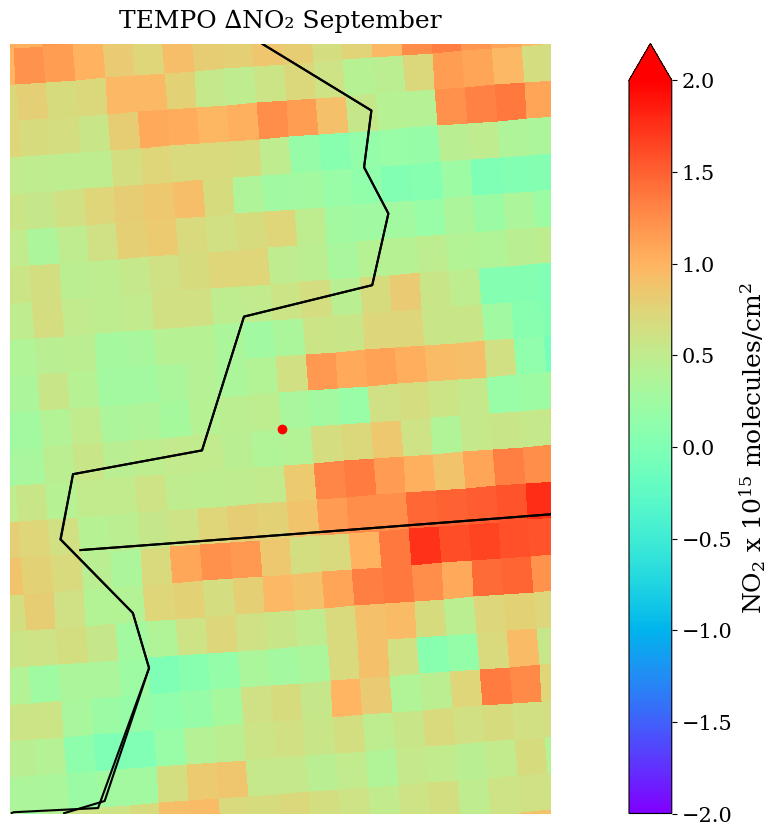

<Figure size 640x480 with 0 Axes>

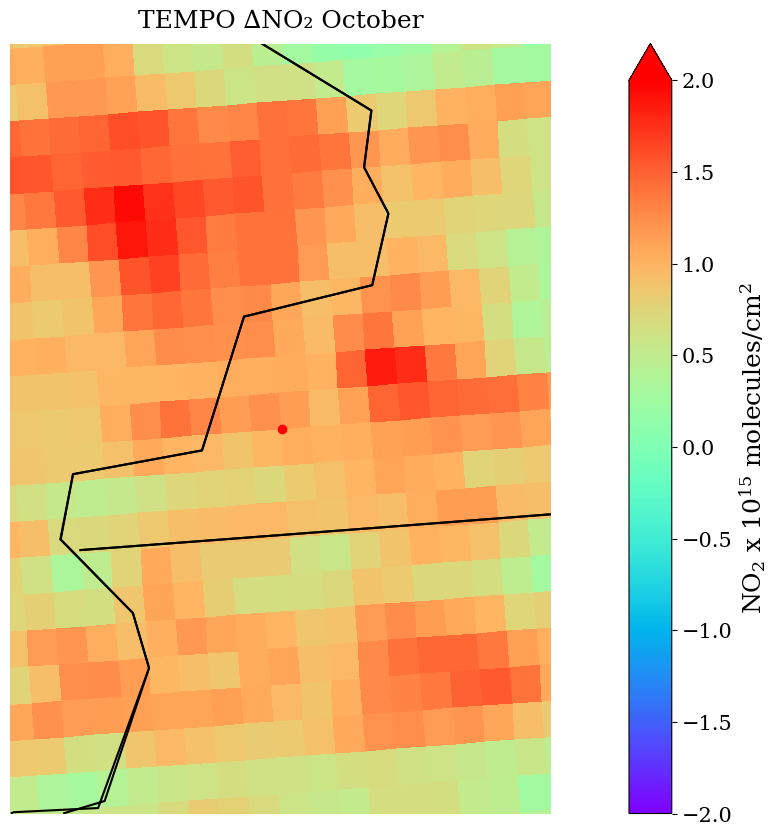

<Figure size 640x480 with 0 Axes>

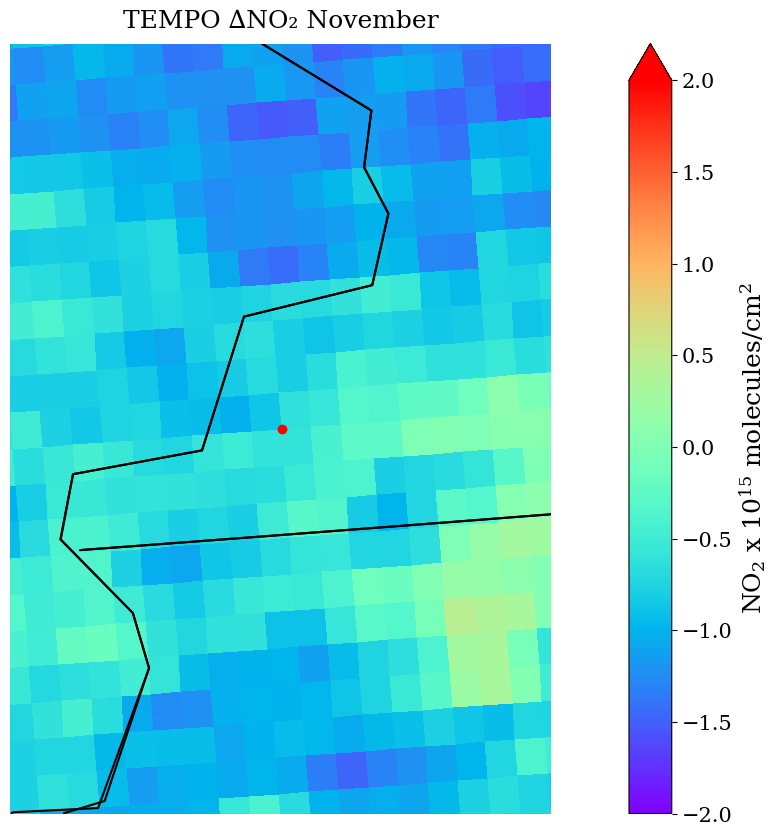

<Figure size 640x480 with 0 Axes>

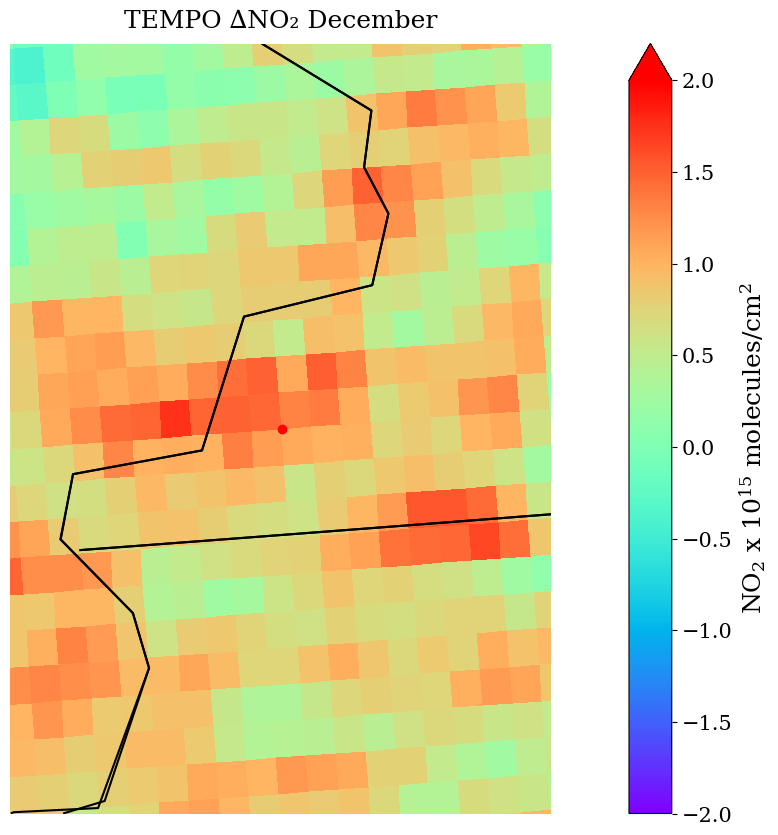

<Figure size 640x480 with 0 Axes>

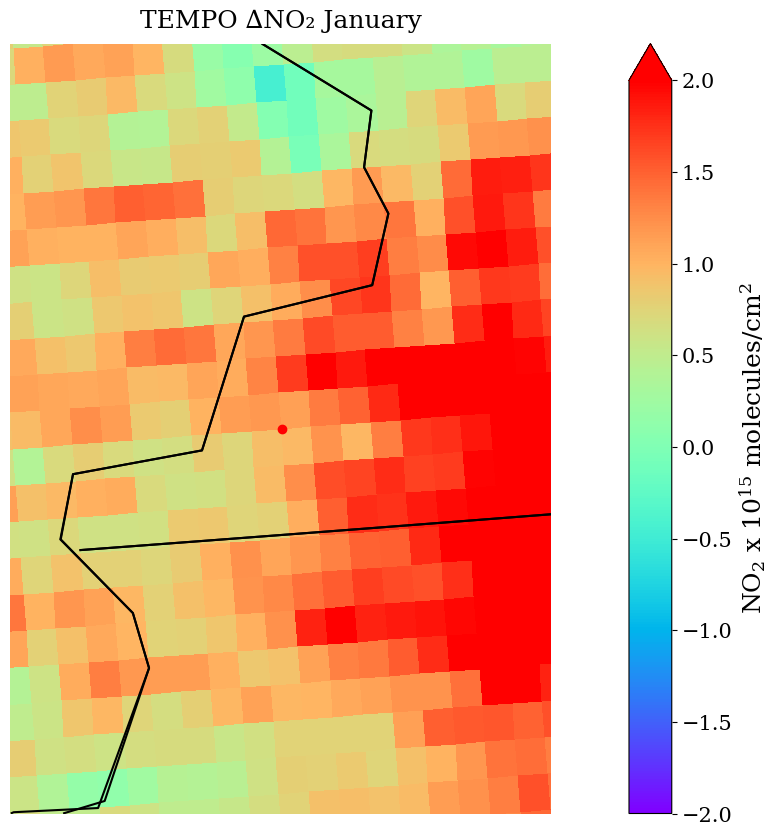

<Figure size 640x480 with 0 Axes>

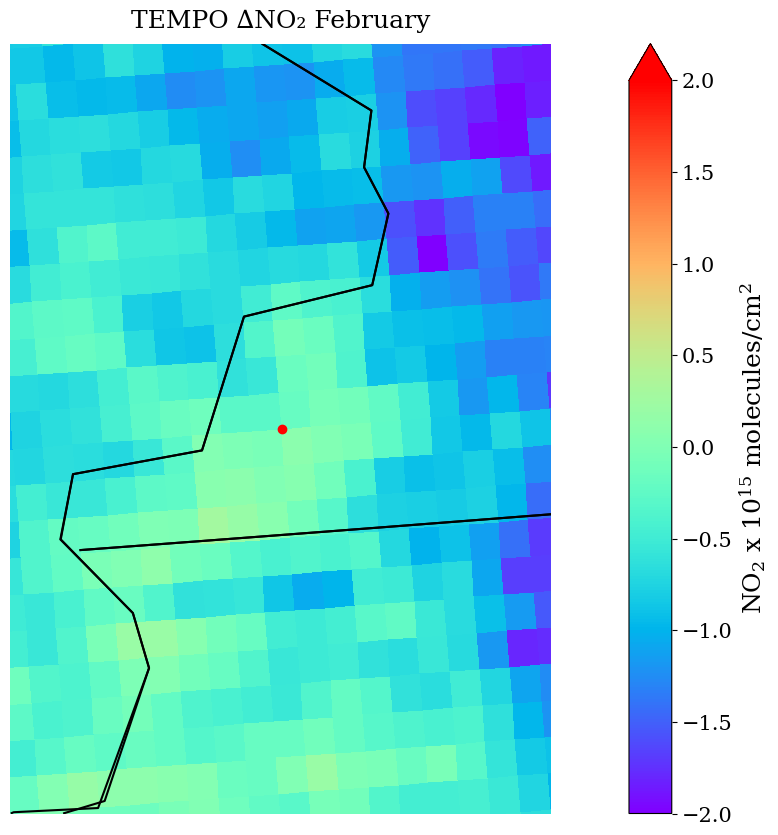

<Figure size 640x480 with 0 Axes>

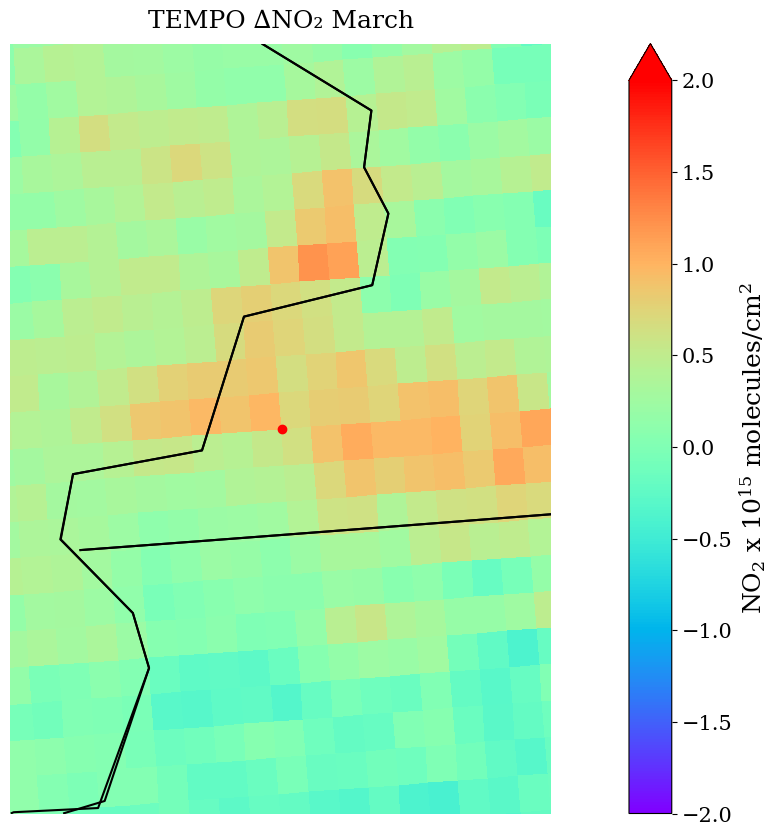

<Figure size 640x480 with 0 Axes>

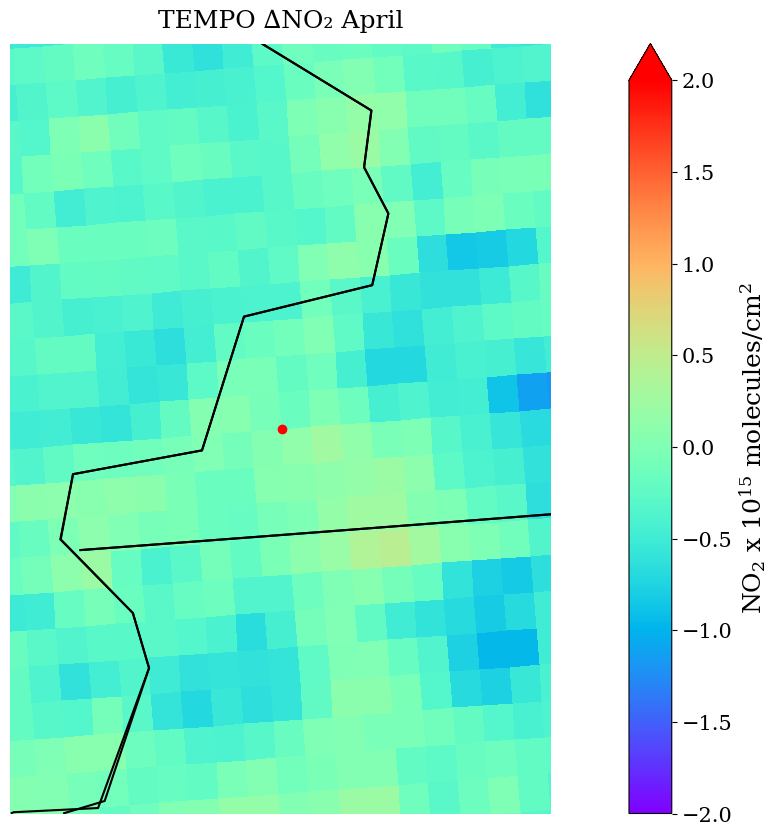

<Figure size 640x480 with 0 Axes>

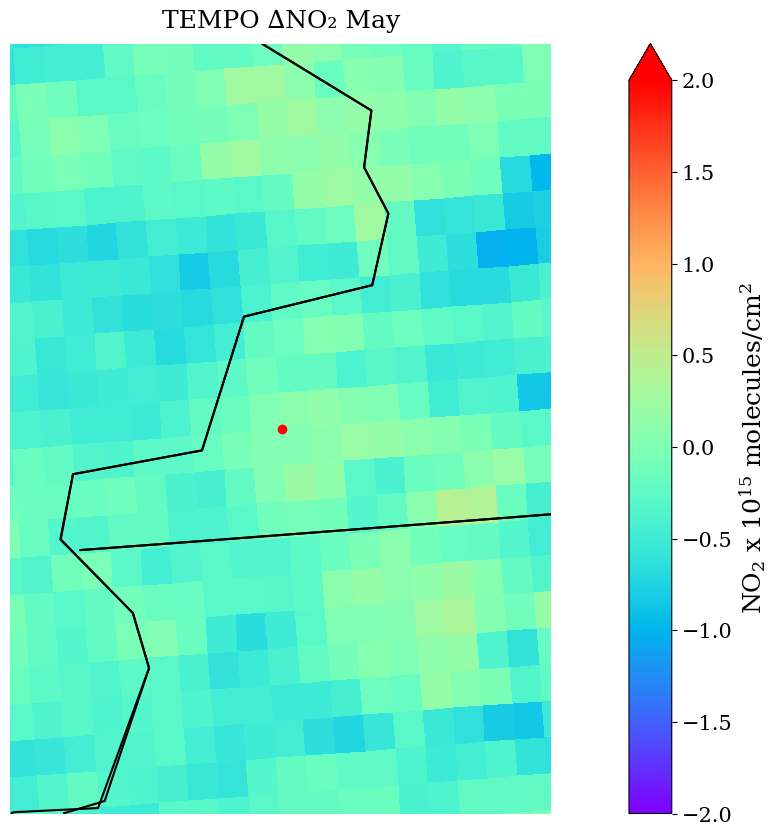

<Figure size 640x480 with 0 Axes>

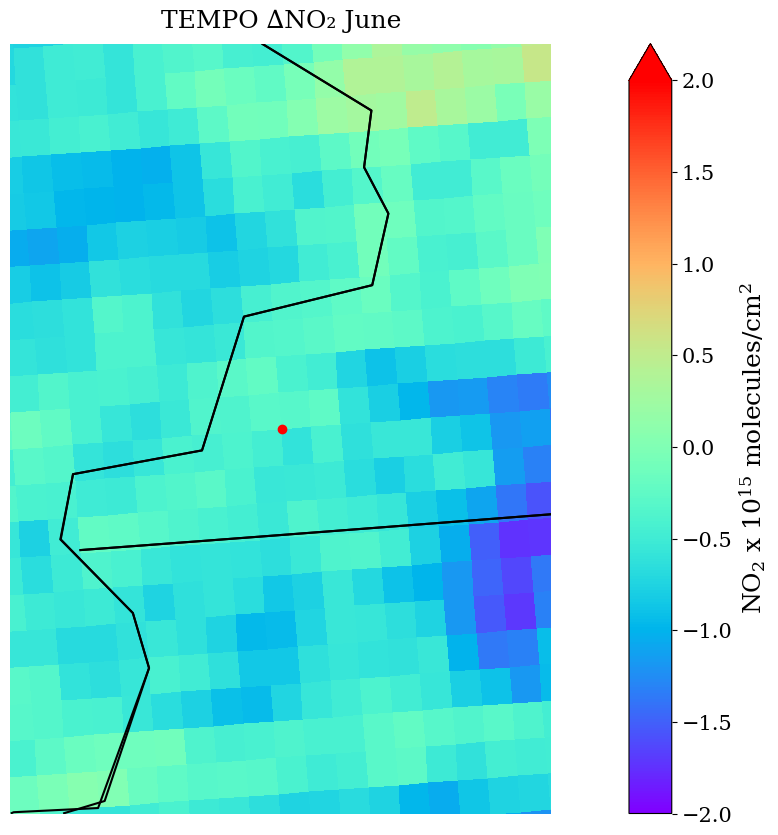

<Figure size 640x480 with 0 Axes>

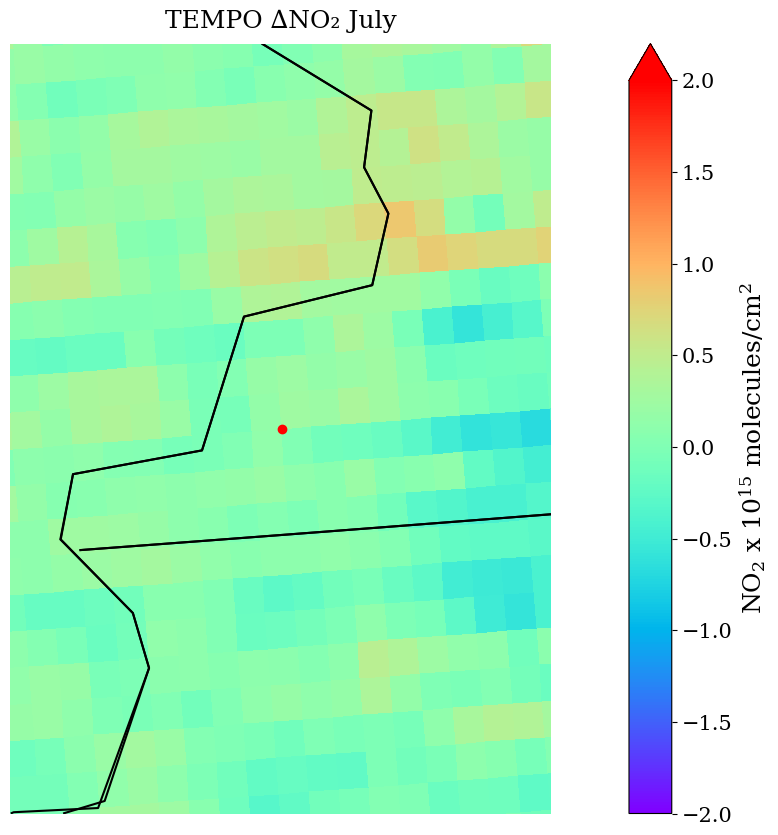

<Figure size 640x480 with 0 Axes>

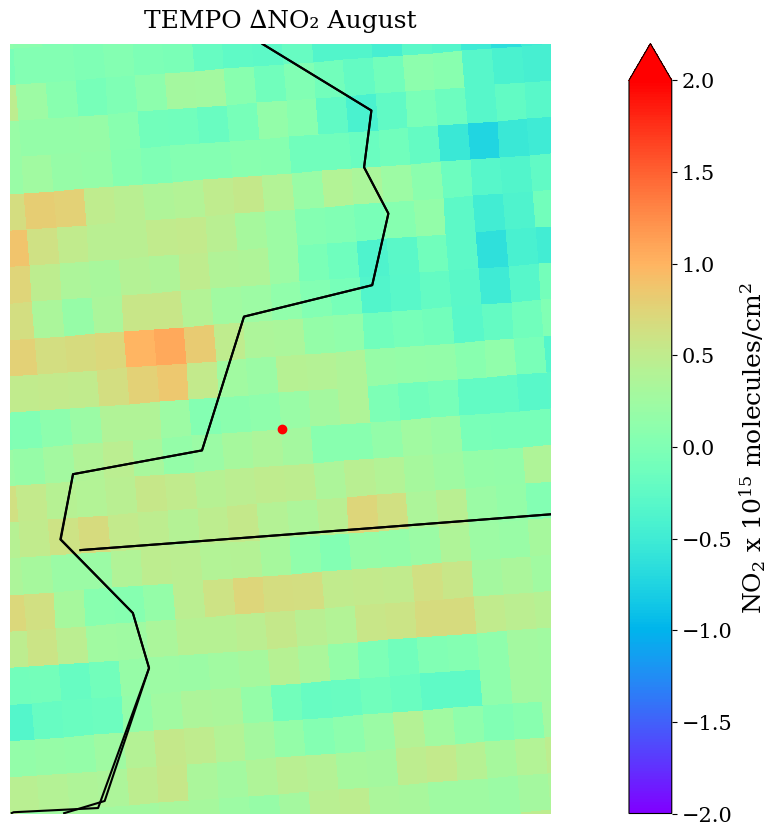

In [14]:
#function to do the ∆NO2 for all 12 months and save the maps as jpegs

def plot_no2_diff(data, month_label, filename,
                  vmin=-2, vmax=2,
                  minlat=34.86, maxlat=35.26,
                  minlon=-90.36, maxlon=-89.96):
    
    plt.clf()
    fig = plt.figure(figsize=(20, 10))
    ax = fig.add_subplot(111, frame_on=False)
    
    m = Basemap(
        projection='lcc', lat_0=40., lat_1=33., lat_2=45., lon_0=-97.,
        resolution='i', area_thresh=10000., rsphere=(6378137.00, 6356752.3142),
        llcrnrlon=minlon, llcrnrlat=minlat, urcrnrlon=maxlon, urcrnrlat=maxlat
    )
    
    try:
        m.drawcoastlines()
    except:
        pass
    m.drawcountries(linewidth=1.5)
    m.drawstates(linewidth=1.5)
    
    colors = 'rainbow'
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    plt.rcParams["font.family"] = "serif"
    
    mesh = m.pcolormesh(data.longitude, data.latitude, data.values,
                        cmap=colors, norm=norm, shading='nearest', latlon=True)
    m.plot(POI_lon, POI_lat, marker='o', color='red', markersize=6, latlon=True)
    
    cbar = plt.colorbar(mesh, aspect=18, extend='max')
    cbar.ax.tick_params(labelsize=15)
    cbar.set_label(label=r'NO$\mathregular{_2}$ x $\mathregular{10^{15}}$ molecules/cm$\mathregular{^2}$',
                   fontsize=18)
    
    plt.title(f'TEMPO ∆NO₂ {month_label}', fontsize=18, y=1.01)
    ##plt.savefig(f'{filename}.jpg', bbox_inches='tight', dpi=300) ## call this out if you dont want jpegs
    plt.show()
    plt.close(fig)  # prevents memory leaks when looping

monthly_data = [
    (no2sepdiff,  'September',  'TEMPO ∆NO₂ September'),
    (no2octdiff,  'October',    'TEMPO ∆NO₂ October'),
    (no2novdiff,  'November',   'TEMPO ∆NO₂ November'),
    (no2decdiff,  'December',   'TEMPO ∆NO₂ December'),
    (no2jandiff,  'January',    'TEMPO ∆NO₂ January'),
    (no2febdiff,  'February',   'TEMPO ∆NO₂ February'),
    (no2mardiff,  'March',      'TEMPO ∆NO₂ March'),
    (no2aprdiff,  'April',      'TEMPO ∆NO₂ April'),
    (no2maydiff,  'May',        'TEMPO ∆NO₂ May'),
    (no2jundiff,  'June',       'TEMPO ∆NO₂ June'),
    (no2juldiff,  'July',       'TEMPO ∆NO₂ July'),
    (no2augdiff,  'August',     'TEMPO ∆NO₂ August'),
]

for data, label, filename in monthly_data:
    plot_no2_diff(data, label, filename)

In [18]:
mergedDS = xr.merge([dsmonth2023, dsmonth2024, dsmonth2025])
mergedDS

/tmp/ipykernel_338764/104682000.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  mergedDS = xr.merge([dsmonth2023, dsmonth2024, dsmonth2025])
/tmp/ipykernel_338764/104682000.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  mergedDS = xr.merge([dsmonth2023, dsmonth2024, dsmonth2025])
/tmp/ipykernel_338764/104682000.py:1: FutureWarning: In a 

<xarray.Dataset> Size: 2MB
Dimensions:    (time: 25, lat: 101, lon: 101)
Coordinates:
  * time       (time) datetime64[ns] 200B 2023-09-30 2023-10-31 ... 2025-09-30
    latitude   (lat, lon) float32 41kB dask.array<chunksize=(101, 101), meta=np.ndarray>
    longitude  (lat, lon) float32 41kB dask.array<chunksize=(101, 101), meta=np.ndarray>
Dimensions without coordinates: lat, lon
Data variables:
    NO2        (time, lat, lon) float64 2MB dask.array<chunksize=(1, 101, 101), meta=np.ndarray>

In [32]:
#get avg values for each month within a 30 km radius

# xAi 35.06, -90.16 (30 km radius from DC)
minlatZOOM = 34.76
maxlatZOOM = 35.36
minlonZOOM = -90.46
maxlonZOOM = -89.86

mask = (mergedDS.latitude >= minlatZOOM) & (mergedDS.latitude <= maxlatZOOM) & (mergedDS.longitude >= minlonZOOM) & (mergedDS.longitude <= maxlonZOOM)
mask_computed = mask.compute()
mergedDS_30km = mergedDS.where(mask_computed, drop=True)

no2_mergedDS = mergedDS_30km['NO2']

csv = no2_mergedDS.to_series().dropna()
csv2 = csv.groupby('time').mean()
##csv2.to_csv('L3_30km_radius_Memphis_NO2_monthly.csv')

